# 02 — 环境搭建与第一个程序

**来源:** [菜鸟教程 — LangGraph 入门教程](https://www.runoob.com/ai-agent/langgraph-quick-start.html)

本 notebook 介绍 LangGraph 的环境搭建步骤，并运行第一个简单的线性工作流。

## 1. 环境搭建

### 安装依赖

```bash
# 创建虚拟环境（推荐）
python -m venv venv
source venv/bin/activate      # macOS/Linux
# venv\Scripts\activate       # Windows

# 安装 LangGraph 和相关依赖（使用国内镜像）
pip install langgraph langchain langchain-openai python-dotenv -i https://mirrors.aliyun.com/pypi/simple/

# 可选：安装开发工具
pip install langgraph-cli jupyter -i https://mirrors.aliyun.com/pypi/simple/
```

### 配置 .env 文件
```
# DeepSeek 配置（国内用户推荐）
DEEPSEEK_API_KEY=sk-xxx
DEEPSEEK_BASE_URL=https://api.deepseek.com
DEEPSEEK_MODEL=deepseek-v4-pro
```

> **提示：** DeepSeek 的 BASE_URL 不带 `/v1`，LangChain 会自动拼接。
> API Key 可在 https://platform.deepseek.com/api_keys 创建。

### 验证安装

In [ ]:
import langgraph
print(f"LangGraph 版本: {langgraph.__version__}")


## 2. 第一个 LangGraph 程序

一个最简单的线性工作流：greet（问候）→ process（处理）。

```mermaid
graph LR
    START --> greet
    greet --> process
    process --> END
```

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


# Step 1: 定义 State
class SimpleState(TypedDict):
    """简单的状态定义"""
    message: str
    processed: bool


# Step 2: 定义节点函数
def greet_node(state: SimpleState) -> dict:
    """欢迎节点：生成问候语"""
    print(f"[greet_node] 收到消息: {state['message']}")
    return {"message": f"你好！{state['message']}"}


def process_node(state: SimpleState) -> dict:
    """处理节点：标记为已处理"""
    print(f"[process_node] 处理消息: {state['message']}")
    return {"processed": True}


# Step 3: 构建图
builder = StateGraph(SimpleState)

# 添加节点
builder.add_node("greet", greet_node)
builder.add_node("process", process_node)

# 添加边
builder.add_edge(START, "greet")
builder.add_edge("greet", "process")
builder.add_edge("process", END)

# Step 4: 编译图
graph = builder.compile()

# Step 5: 运行工作流
result = graph.invoke({
    "message": "世界",
    "processed": False
})

print(f"\n最终结果: {result}")


[greet_node] 收到消息: 世界
[process_node] 处理消息: 你好！世界

最终结果: {'message': '你好！世界', 'processed': True}


### 可视化图结构

在 Jupyter Notebook 中可以直接可视化图结构：

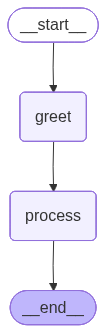

Mermaid 格式:
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	greet(greet)
	process(process)
	__end__([<p>__end__</p>]):::last
	__start__ --> greet;
	greet --> process;
	process --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))
print("Mermaid 格式:")
print(graph.get_graph().draw_mermaid())
